In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

In [2]:
df = pd.read_csv("tokyo_weather.csv")

df["Date"] = pd.to_datetime(df["Date"])


df = df.set_index("Date")

# Column we want to predict
TARGET = "Highest Temperature (°C)"

# Convert all columns to numeric values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [3]:

def create_features(data):
    """
    Create date-based features from the Date index.
    These help the model learn seasonal patterns.
    """
    data = data.copy()

    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["dayofmonth"] = data.index.day
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    
    ##test features

    


    return data


def add_lags(data):
    """
    Create lag features.
    These tell the model what the temperature was on previous days.
    """
    data = data.copy()

    data["lag1_day"] = data[TARGET].shift(1)
    data["lag2_day"] = data[TARGET].shift(2)
    data["lag3_day"] = data[TARGET].shift(3)
    data["lag7_day"] = data[TARGET].shift(7)

    #test
    data["rolling_7"] = data[TARGET].shift(1).rolling(7).mean()
    data["rolling_3"] = data[TARGET].shift(1).rolling(3).mean()
    data["rolling_2"] = data[TARGET].shift(1).rolling(2).mean()
    
    data["diff_from_avg_7"] = data[TARGET].shift(1) - data["rolling_7"]

    return data


df = create_features(df)
df = add_lags(df)

# Remove rows where lag values are missing
needed_cols = [TARGET, "lag1_day", "lag2_day", "lag3_day", "lag7_day"]
df = df.dropna(subset=needed_cols)



In [4]:
# Use every column except the target as input features for training
FEATURES = [col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

In [ ]:
# Time series cross-validation

# Number of time-series validation folds
n_splits = 5

# Use up to 15 days for each validation fold
test_size = min(15, len(df) // (n_splits + 1))

tss = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

mae_scores = []
rmse_scores = []
mape_scores = []

for fold, (train_idx, val_idx) in enumerate(tss.split(df), start=1):

    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

  
    model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict validation values
    preds = model.predict(X_test)

    # Calculate errors
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # Calculate MAPE
    ape = np.abs((y_test.values - preds) / y_test.values)
    ape = ape[np.isfinite(ape)]
    mape = np.mean(ape) * 100

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    mape_scores.append(mape)

    print(f"Fold {fold}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape, "%")
    print("-" * 30)



print("Average CV MAE:", np.mean(mae_scores))
print("Average CV RMSE:", np.mean(rmse_scores))
print("Average CV MAPE:", np.mean(mape_scores), "%")


# --------------------------------------------------
# Final last-15-days test
# --------------------------------------------------

# Use the last 15 days as final test set
final_test_size = min(15, len(df) // 5)

train_df = df.iloc[:-final_test_size]
test_df = df.iloc[-final_test_size:]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Train final model
final_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42
)

final_model.fit(X_train, y_train)

# Predict final test set
final_preds = final_model.predict(X_test)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3793
[LightGBM] [Info] Number of data points in the train set: 2111, number of used features: 23
[LightGBM] [Info] Start training from score 21.263051
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Date,Actual,Predicted,Error,Absolute Error,APE,APE (%)
0,2024-06-12,30.1,29.858893,0.241107,0.241107,0.008010,0.801019
1,2024-06-13,25.4,26.695000,-1.295000,1.295000,0.050984,5.098423
2,2024-06-14,31.7,31.557360,0.142640,0.142640,0.004500,0.449969
3,2024-06-15,29.9,29.958407,-0.058407,0.058407,0.001953,0.195342
4,2024-06-16,28.7,29.209880,-0.509880,0.509880,0.017766,1.776587
5,2024-06-17,30.5,31.177520,-0.677520,0.677520,0.022214,2.221378
6,2024-06-18,22.5,20.596766,1.903234,1.903234,0.084588,8.458819
7,2024-06-19,29.5,29.224858,0.275142,0.275142,0.009327,0.932686
8,2024-06-20,28.4,29.163201,-0.763201,0.763201,0.026873,2.687327
9,2024-06-21,23.3,22.661294,0.638706,0.638706,0.027412,2.741226


Final MAE: 0.7419910460224195
Final RMSE: 0.9623110374517956
Final MAPE: 2.766730696665166 %


,Feature,Importance
0,Average Temperature (°C),1587
19,Minimum Relative Humidity (%),803
5,Sunshine Duration (hours),757
2,Lowest Temperature (°C),703
17,Average Vapor Pressure (hPa),534
9,Average Wind Speed (m/s),489
13,Maximum Gust Speed (m/s),408
33,diff_from_avg_7,343
18,Average Humidity (%),336
28,lag3_day,265


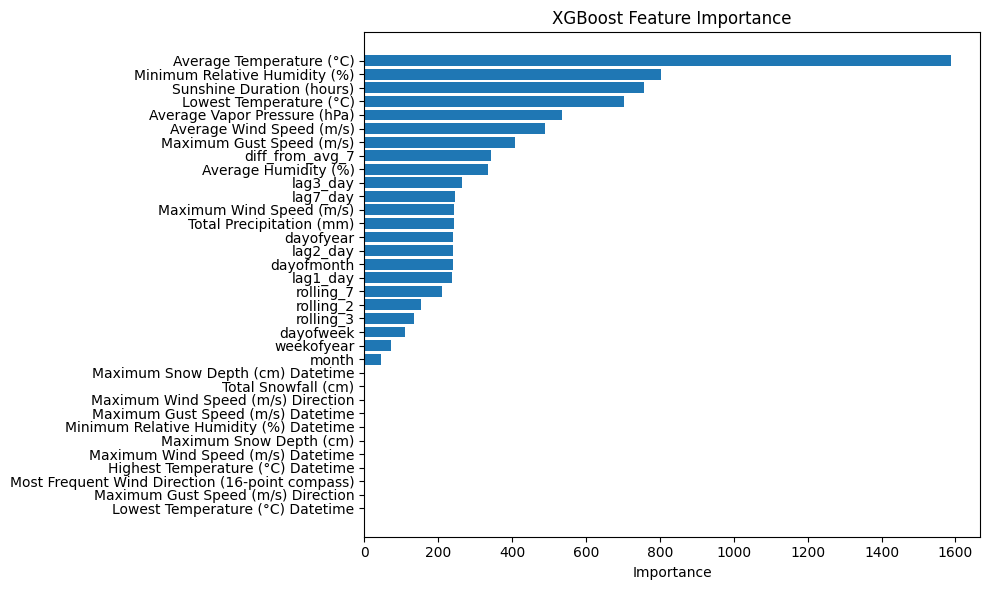

In [6]:
# Create comparison table
comparison_table = pd.DataFrame({
    "Date": test_df.index,
    "Actual": y_test.values,
    "Predicted": final_preds
})

# Error calculations
comparison_table["Error"] = comparison_table["Actual"] - comparison_table["Predicted"]
comparison_table["Absolute Error"] = comparison_table["Error"].abs()

# Absolute percentage error for MAPE
comparison_table["APE"] = np.abs(
    comparison_table["Error"] / comparison_table["Actual"]
)

# Remove infinity values caused by division by zero
comparison_table = comparison_table.replace([np.inf, -np.inf], np.nan)

# Convert APE to percentage
comparison_table["APE (%)"] = comparison_table["APE"] * 100

display(comparison_table)

# Final test errors
final_mae = mean_absolute_error(comparison_table["Actual"], comparison_table["Predicted"])
final_rmse = np.sqrt(mean_squared_error(comparison_table["Actual"], comparison_table["Predicted"]))
final_mape = comparison_table["APE"].dropna().mean() * 100

print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)
print("Final MAPE:", final_mape, "%")

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()